Linear Regression
R2 Score: 0.3877910586849749
MSE: 947.3502490715092
--------------------------------------------------


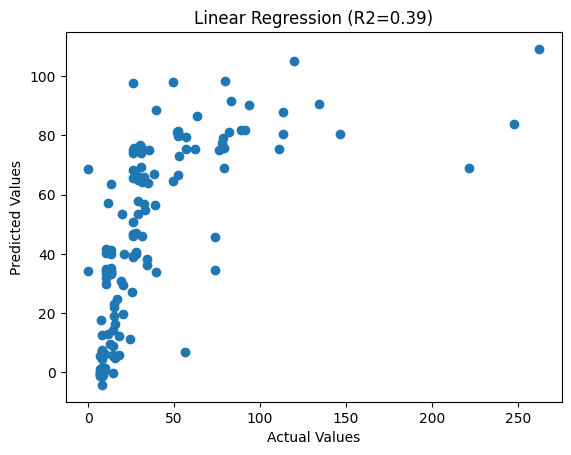

Polynomial Regression
R2 Score: 0.3828042308198758
MSE: 955.0670142169686
--------------------------------------------------


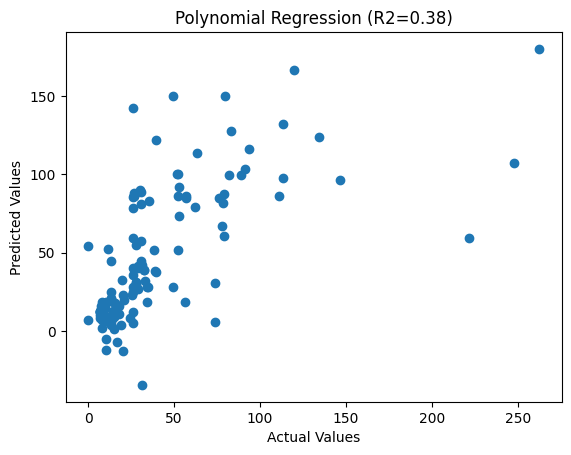

Decision Tree Regression
R2 Score: -0.4169112241225754
MSE: 2192.570396311844
--------------------------------------------------


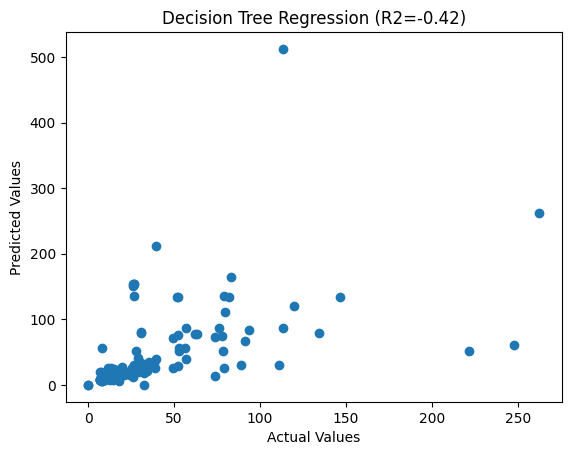

Random Forest Regression
R2 Score: 0.3286263251628744
MSE: 1038.9035101493637
--------------------------------------------------


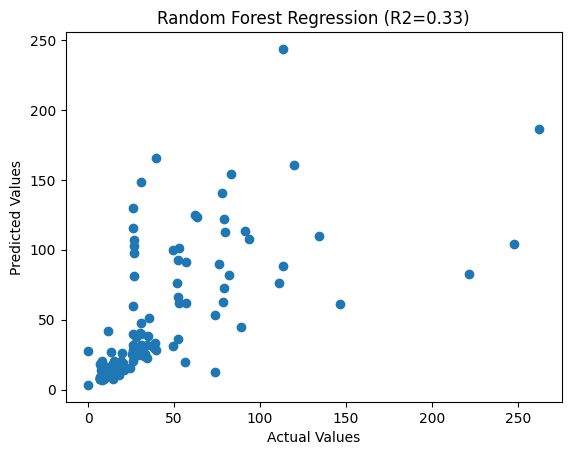

Support Vector Regression
R2 Score: 0.2502860342341381
MSE: 1160.1295967273504
--------------------------------------------------


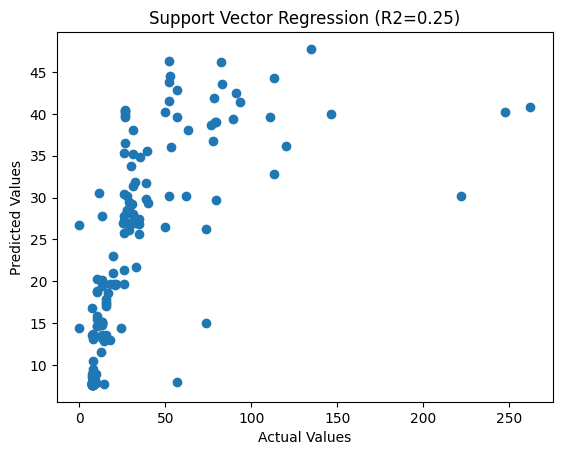

Ridge Regression
R2 Score: 0.3881919852405271
MSE: 946.7298434442313
--------------------------------------------------


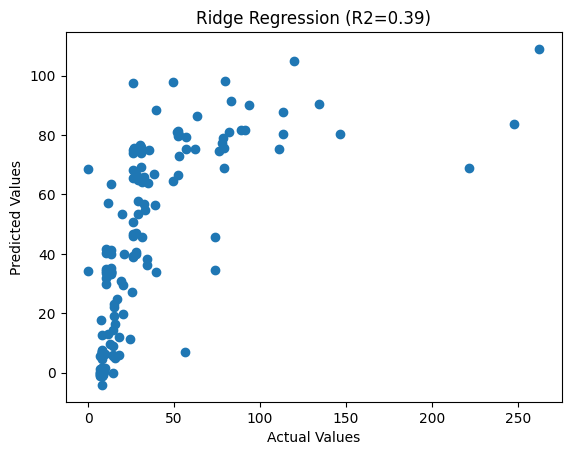

Lasso Regression
R2 Score: 0.3978187689202476
MSE: 931.8330732383746
--------------------------------------------------


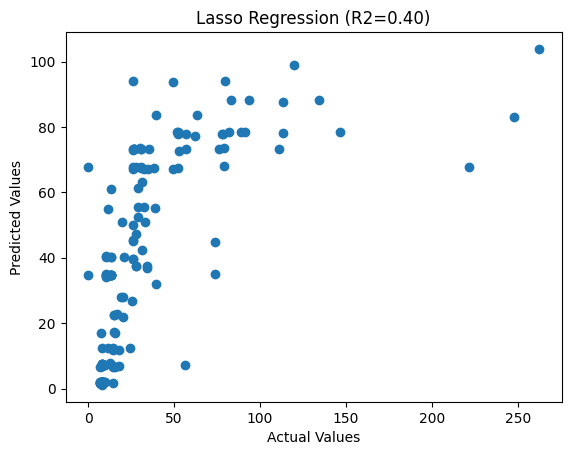

ElasticNet Regression
R2 Score: 0.41325673910214344
MSE: 907.9439009150127
--------------------------------------------------


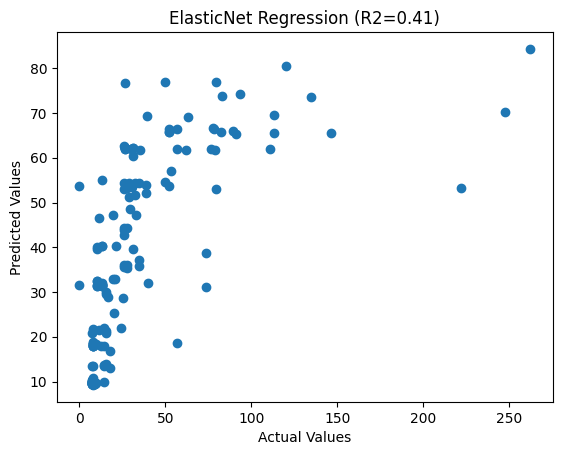

Bayesian Linear Regression
R2 Score: 0.39205528343678075
MSE: 940.751661386653
--------------------------------------------------


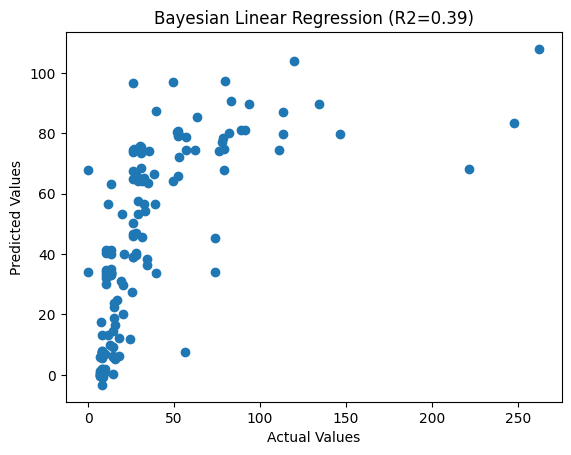

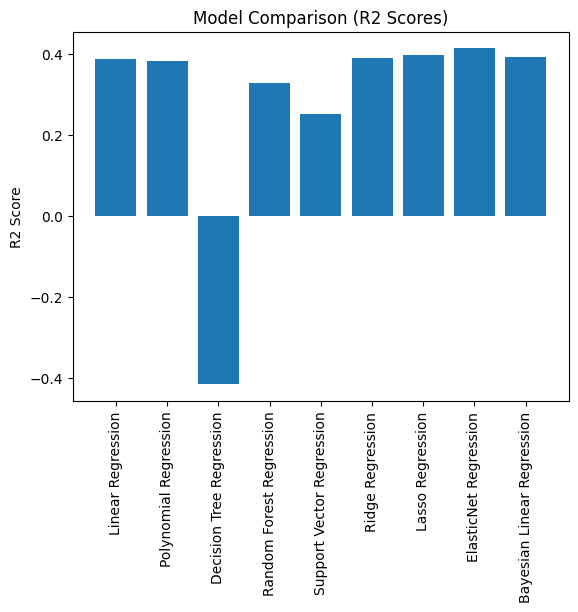

In [3]:
# ==============================
# COMPLETE REGRESSION WITH GRAPHS
# ==============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, BayesianRidge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score

# Load Dataset
df = pd.read_csv("/content/Titanic-Dataset.csv")

# Keep numeric columns only
df = df.select_dtypes(include=np.number)
df = df.fillna(df.mean())

# Target column (change if needed)
target_column = df.columns[-1]
X = df.drop(target_column, axis=1)
y = df[target_column]

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Store R2 scores
r2_scores = {}

# Function to Train, Predict & Plot
def evaluate_and_plot(name, model, X_tr, X_te):
    model.fit(X_tr, y_train)
    y_pred = model.predict(X_te)

    r2 = r2_score(y_test, y_pred)
    r2_scores[name] = r2

    print(f"{name}")
    print("R2 Score:", r2)
    print("MSE:", mean_squared_error(y_test, y_pred))
    print("-"*50)

    # Plot
    plt.figure()
    plt.scatter(y_test, y_pred)
    plt.xlabel("Actual Values")
    plt.ylabel("Predicted Values")
    plt.title(f"{name} (R2={r2:.2f})")
    plt.show()

# ==============================
# Train All Models + Graphs
# ==============================

# 1 Linear
evaluate_and_plot("Linear Regression", LinearRegression(), X_train, X_test)

# 2 Polynomial
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)
evaluate_and_plot("Polynomial Regression", LinearRegression(), X_train_poly, X_test_poly)

# 3 Decision Tree
evaluate_and_plot("Decision Tree Regression", DecisionTreeRegressor(), X_train, X_test)

# 4 Random Forest
evaluate_and_plot("Random Forest Regression", RandomForestRegressor(), X_train, X_test)

# 5 SVR
evaluate_and_plot("Support Vector Regression", SVR(), X_train, X_test)

# 6 Ridge
evaluate_and_plot("Ridge Regression", Ridge(), X_train, X_test)

# 7 Lasso
evaluate_and_plot("Lasso Regression", Lasso(), X_train, X_test)

# 8 ElasticNet
evaluate_and_plot("ElasticNet Regression", ElasticNet(), X_train, X_test)

# 9 Bayesian
evaluate_and_plot("Bayesian Linear Regression", BayesianRidge(), X_train, X_test)

# ==============================
# Final Comparison Graph
# ==============================

plt.figure()
plt.bar(r2_scores.keys(), r2_scores.values())
plt.xticks(rotation=90)
plt.ylabel("R2 Score")
plt.title("Model Comparison (R2 Scores)")
plt.show()